# Trabajo Práctico Nº 2
## Ángulos de Euler, Gimbal Lock y Validación Simbólica/Numérica

**Estudiante:** Valeria Alejandra Hoyos Tovar  
**Carrera:** Ingeniería Mecatrónica  
**Asignatura:** IMT-342 Robotica




# Ejercicio 1 – Deducción simbólica y extracción de ángulos RPY




## 1.1 Matrices elementales

\[
R_x(\alpha)=
\begin{bmatrix}
1&0&0\\
0&\cos\alpha&-\sin\alpha\\
0&\sin\alpha&\cos\alpha
\end{bmatrix}
\]

\[
R_y(\beta)=
\begin{bmatrix}
\cos\beta&0&\sin\beta\\
0&1&0\\
-\sin\beta&0&\cos\beta
\end{bmatrix}
\]

\[
R_z(\gamma)=
\begin{bmatrix}
\cos\gamma&-\sin\gamma&0\\
\sin\gamma&\cos\gamma&0\\
0&0&1
\end{bmatrix}
\]


In [1]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

sp.init_printing()
print("Librerías importadas correctamente.")

Librerías importadas correctamente.


## 1.2 Multiplicación simbólica de la matriz RPY

Calculamos:

\[
R_{RPY}=R_z(\gamma)R_y(\beta)R_x(\alpha)
\]


In [2]:
alpha, beta, gamma = sp.symbols('alpha beta gamma', real=True)

Rx = sp.Matrix([
    [1, 0, 0],
    [0, sp.cos(alpha), -sp.sin(alpha)],
    [0, sp.sin(alpha), sp.cos(alpha)]
])

Ry = sp.Matrix([
    [sp.cos(beta), 0, sp.sin(beta)],
    [0, 1, 0],
    [-sp.sin(beta), 0, sp.cos(beta)]
])

Rz = sp.Matrix([
    [sp.cos(gamma), -sp.sin(gamma), 0],
    [sp.sin(gamma), sp.cos(gamma), 0],
    [0, 0, 1]
])

R_RPY = sp.simplify(Rz * Ry * Rx)

print("Matriz RPY = Rz(gamma) * Ry(beta) * Rx(alpha):")
display(R_RPY)

Matriz RPY = Rz(gamma) * Ry(beta) * Rx(alpha):


⎡cos(β)⋅cos(γ)  sin(α)⋅sin(β)⋅cos(γ) - sin(γ)⋅cos(α)  sin(α)⋅sin(γ) + sin(β)⋅c ↪
⎢                                                                              ↪
⎢sin(γ)⋅cos(β)  sin(α)⋅sin(β)⋅sin(γ) + cos(α)⋅cos(γ)  -sin(α)⋅cos(γ) + sin(β)⋅ ↪
⎢                                                                              ↪
⎣   -sin(β)                sin(α)⋅cos(β)                          cos(α)⋅cos(β ↪

↪ os(α)⋅cos(γ) ⎤
↪              ⎥
↪ sin(γ)⋅cos(α)⎥
↪              ⎥
↪ )            ⎦

La matriz resultante es:

\[
R=
\begin{bmatrix}
c_\gamma c_\beta &
c_\gamma s_\beta s_\alpha-s_\gamma c_\alpha &
c_\gamma s_\beta c_\alpha+s_\gamma s_\alpha\\
s_\gamma c_\beta &
s_\gamma s_\beta s_\alpha+c_\gamma c_\alpha &
s_\gamma s_\beta c_\alpha-c_\gamma s_\alpha\\
-s_\beta &
c_\beta s_\alpha &
c_\beta c_\alpha
\end{bmatrix}
\]

donde \(c_x=\cos(x)\) y \(s_x=\sin(x)\).


## 1.3 Extracción de los ángulos

Sea:

\[
R=
\begin{bmatrix}
r_{11}&r_{12}&r_{13}\\
r_{21}&r_{22}&r_{23}\\
r_{31}&r_{32}&r_{33}
\end{bmatrix}
\]

Comparando con la matriz anterior:

\[
r_{31}=-\sin\beta
\]



# Ejercicio 2 – Análisis del Gimbal Lock mediante SymPy



In [3]:
# Variables simbólicas
phi, theta, psi = sp.symbols('phi theta psi', real=True)

# Rz(phi)
Rz_phi = sp.Matrix([
    [sp.cos(phi), -sp.sin(phi), 0],
    [sp.sin(phi),  sp.cos(phi), 0],
    [0, 0, 1]
])

# Ry(theta)
Ry_theta = sp.Matrix([
    [sp.cos(theta), 0, sp.sin(theta)],
    [0, 1, 0],
    [-sp.sin(theta), 0, sp.cos(theta)]
])

# Rz(psi)
Rz_psi = sp.Matrix([
    [sp.cos(psi), -sp.sin(psi), 0],
    [sp.sin(psi),  sp.cos(psi), 0],
    [0, 0, 1]
])

# Matriz total ZYZ
R_ZYZ = sp.simplify(Rz_phi * Ry_theta * Rz_psi)

print("Matriz simbólica R_ZYZ:")
display(R_ZYZ)

Matriz simbólica R_ZYZ:


⎡-sin(φ)⋅sin(ψ) + cos(φ)⋅cos(ψ)⋅cos(θ)  -sin(φ)⋅cos(ψ) - sin(ψ)⋅cos(φ)⋅cos(θ)  ↪
⎢                                                                              ↪
⎢sin(φ)⋅cos(ψ)⋅cos(θ) + sin(ψ)⋅cos(φ)   -sin(φ)⋅sin(ψ)⋅cos(θ) + cos(φ)⋅cos(ψ)  ↪
⎢                                                                              ↪
⎣           -sin(θ)⋅cos(ψ)                          sin(ψ)⋅sin(θ)              ↪

↪  sin(θ)⋅cos(φ)⎤
↪               ⎥
↪  sin(φ)⋅sin(θ)⎥
↪               ⎥
↪     cos(θ)    ⎦

## 2.1 Evaluación de la singularidad: \(\theta=0\)

Al sustituir:

\[
\theta=0
\]

se obtiene:

\[
R_{ZYZ}=R_z(\phi)R_y(0)R_z(\psi)
\]

Como \(R_y(0)=I\), queda:

\[
R_{ZYZ}=R_z(\phi)R_z(\psi)=R_z(\phi+\psi)
\]

Por lo tanto, únicamente puede identificarse la suma \(\phi+\psi\).


In [4]:
R_singular = sp.simplify(R_ZYZ.subs(theta, 0))

print("Matriz R_ZYZ para theta = 0:")
display(R_singular)

alpha_aux = sp.symbols('alpha_aux', real=True)

R_expected = sp.Matrix([
    [sp.cos(alpha_aux), -sp.sin(alpha_aux), 0],
    [sp.sin(alpha_aux),  sp.cos(alpha_aux), 0],
    [0, 0, 1]
])

comprobacion = sp.simplify(
    R_singular - R_expected.subs(alpha_aux, phi + psi)
)

print("Diferencia entre R_singular y Rz(phi + psi):")
display(comprobacion)

print("¿Son exactamente iguales?", comprobacion == sp.zeros(3))

Matriz R_ZYZ para theta = 0:


⎡cos(φ + ψ)  -sin(φ + ψ)  0⎤
⎢                          ⎥
⎢sin(φ + ψ)  cos(φ + ψ)   0⎥
⎢                          ⎥
⎣    0            0       1⎦

Diferencia entre R_singular y Rz(phi + psi):


⎡0  0  0⎤
⎢       ⎥
⎢0  0  0⎥
⎢       ⎥
⎣0  0  0⎦

¿Son exactamente iguales? True


## 2.2 Dependencia lineal de las derivadas

Si ambas derivadas son iguales, significa que cambiar \(\phi\) o \(\psi\) produce la misma dirección de variación local de la orientación. Por ello se pierde un grado de libertad representacional.


In [5]:
dR_dphi = sp.diff(R_ZYZ, phi)
dR_dpsi = sp.diff(R_ZYZ, psi)

dR_dphi_singular = sp.simplify(dR_dphi.subs(theta, 0))
dR_dpsi_singular = sp.simplify(dR_dpsi.subs(theta, 0))

print("Derivada respecto a phi para theta = 0:")
display(dR_dphi_singular)

print("Derivada respecto a psi para theta = 0:")
display(dR_dpsi_singular)

diferencia_derivadas = sp.simplify(
    dR_dphi_singular - dR_dpsi_singular
)

print("Diferencia entre ambas derivadas:")
display(diferencia_derivadas)

print("¿Las derivadas son iguales?",
      diferencia_derivadas == sp.zeros(3))

if diferencia_derivadas == sp.zeros(3):
    print("\nRESULTADO: GIMBAL LOCK DETECTADO")
    print("Las variables phi y psi son localmente dependientes.")
    print("Se pierde un grado de libertad representacional.")

Derivada respecto a phi para theta = 0:


⎡-sin(φ + ψ)  -cos(φ + ψ)  0⎤
⎢                           ⎥
⎢cos(φ + ψ)   -sin(φ + ψ)  0⎥
⎢                           ⎥
⎣     0            0       0⎦

Derivada respecto a psi para theta = 0:


⎡-sin(φ + ψ)  -cos(φ + ψ)  0⎤
⎢                           ⎥
⎢cos(φ + ψ)   -sin(φ + ψ)  0⎥
⎢                           ⎥
⎣     0            0       0⎦

Diferencia entre ambas derivadas:


⎡0  0  0⎤
⎢       ⎥
⎢0  0  0⎥
⎢       ⎥
⎣0  0  0⎦

¿Las derivadas son iguales? True

RESULTADO: GIMBAL LOCK DETECTADO
Las variables phi y psi son localmente dependientes.
Se pierde un grado de libertad representacional.


# Ejercicio 3 – Simulación numérica del caso ABB IRB 120




In [8]:
# ============================================================
# FUNCIONES DE ROTACIÓN NUMÉRICAS
# ============================================================

def Rz_num(angle):
    c = np.cos(angle)
    s = np.sin(angle)

    return np.array([
        [c, -s, 0.0],
        [s,  c, 0.0],
        [0.0, 0.0, 1.0]
    ])


def Ry_num(angle):
    c = np.cos(angle)
    s = np.sin(angle)

    return np.array([
        [c, 0.0, s],
        [0.0, 1.0, 0.0],
        [-s, 0.0, c]
    ])


def matriz_ZYZ(phi, theta, psi):
    return Rz_num(phi) @ Ry_num(theta) @ Rz_num(psi)


# ============================================================
# EXTRACCIÓN DE ÁNGULOS ZYZ
# ============================================================

def extraer_ZYZ(R):
    # El término sin(theta) puede obtenerse a partir de la
    # tercera columna de la matriz.
    sin_theta = np.sqrt(R[0, 2]**2 + R[1, 2]**2)

    theta = np.arctan2(sin_theta, R[2, 2])

    # Umbral para identificar una condición numéricamente singular
    if sin_theta > 1e-10:
        phi = np.arctan2(R[1, 2], R[0, 2])
        psi = np.arctan2(R[2, 1], -R[2, 0])
        singular = False
    else:
        # En theta = 0 solo se conoce phi + psi
        phi = np.arctan2(R[1, 0], R[0, 0])
        psi = 0.0
        singular = True

    return phi, theta, psi, singular

## 3.1 Caso 1: \(\theta=0.0001^\circ\)

Primero se calcula la matriz de rotación y posteriormente se intentan recuperar los tres ángulos.


In [7]:
phi_real_deg = 45.0
theta_real_deg = 0.0001
psi_real_deg = 30.0

phi_real = np.deg2rad(phi_real_deg)
theta_real = np.deg2rad(theta_real_deg)
psi_real = np.deg2rad(psi_real_deg)

R_caso1 = matriz_ZYZ(phi_real, theta_real, psi_real)

phi_calc, theta_calc, psi_calc, singular = extraer_ZYZ(R_caso1)

print("MATRIZ R_ZYZ:")
print(R_caso1)

print("\nÁNGULOS REALES (grados)")
print(f"phi   = {phi_real_deg}")
print(f"theta = {theta_real_deg}")
print(f"psi   = {psi_real_deg}")

print("\nÁNGULOS CALCULADOS (grados)")
print(f"phi   = {np.rad2deg(phi_calc)}")
print(f"theta = {np.rad2deg(theta_calc)}")
print(f"psi   = {np.rad2deg(psi_calc)}")

print("\n¿Caso tratado como singular?", singular)

MATRIZ R_ZYZ:
[[ 2.58819045e-01 -9.65925826e-01  1.23413415e-06]
 [ 9.65925826e-01  2.58819045e-01  1.23413415e-06]
 [-1.51149947e-06  8.72664626e-07  1.00000000e+00]]

ÁNGULOS REALES (grados)
phi   = 45.0
theta = 0.0001
psi   = 30.0

ÁNGULOS CALCULADOS (grados)
phi   = 45.0
theta = 0.00010000000000000002
psi   = 29.999999999999996

¿Caso tratado como singular? False


## 3.2 Caso 2: extremadamente cerca de la singularidad

Ahora se utiliza:

\[
\theta=0.00000000001^\circ
\]

Este valor es extremadamente pequeño. La información que permite separar \(\phi\) de \(\psi\) se vuelve numéricamente muy sensible.


In [9]:
theta_extremo_deg = 0.00000000001

theta_extremo = np.deg2rad(theta_extremo_deg)

R_caso2 = matriz_ZYZ(
    phi_real,
    theta_extremo,
    psi_real
)

phi_calc2, theta_calc2, psi_calc2, singular2 = extraer_ZYZ(R_caso2)

print("MATRIZ R_ZYZ:")
print(R_caso2)

print("\nÁNGULOS REALES (grados)")
print(f"phi   = {phi_real_deg}")
print(f"theta = {theta_extremo_deg}")
print(f"psi   = {psi_real_deg}")

print("\nÁNGULOS CALCULADOS (grados)")
print(f"phi   = {np.rad2deg(phi_calc2)}")
print(f"theta = {np.rad2deg(theta_calc2)}")
print(f"psi   = {np.rad2deg(psi_calc2)}")

print("\n¿Caso tratado como singular?", singular2)

print("\nEn la condición singular, la extracción asigna psi = 0")
print("y concentra la orientación observable en el ángulo phi.")

MATRIZ R_ZYZ:
[[ 2.58819045e-01 -9.65925826e-01  1.23413415e-13]
 [ 9.65925826e-01  2.58819045e-01  1.23413415e-13]
 [-1.51149947e-13  8.72664626e-14  1.00000000e+00]]

ÁNGULOS REALES (grados)
phi   = 45.0
theta = 1e-11
psi   = 30.0

ÁNGULOS CALCULADOS (grados)
phi   = 74.99999999999999
theta = 1e-11
psi   = 0.0

¿Caso tratado como singular? True

En la condición singular, la extracción asigna psi = 0
y concentra la orientación observable en el ángulo phi.


## 3.3 Comparación de los resultados

Se calcula el error absoluto de extracción para ambos casos.


In [10]:
phi_error1 = abs(phi_real_deg - np.rad2deg(phi_calc))
theta_error1 = abs(theta_real_deg - np.rad2deg(theta_calc))
psi_error1 = abs(psi_real_deg - np.rad2deg(psi_calc))

phi_error2 = abs(phi_real_deg - np.rad2deg(phi_calc2))
theta_error2 = abs(theta_extremo_deg - np.rad2deg(theta_calc2))
psi_error2 = abs(psi_real_deg - np.rad2deg(psi_calc2))

print("ERRORES DEL CASO 1")
print(f"Error phi   = {phi_error1:.12e} grados")
print(f"Error theta = {theta_error1:.12e} grados")
print(f"Error psi   = {psi_error1:.12e} grados")

print("\nERRORES DEL CASO 2")
print(f"Error phi   = {phi_error2:.12e} grados")
print(f"Error theta = {theta_error2:.12e} grados")
print(f"Error psi   = {psi_error2:.12e} grados")

ERRORES DEL CASO 1
Error phi   = 0.000000000000e+00 grados
Error theta = 1.355252715607e-20 grados
Error psi   = 3.552713678801e-15 grados

ERRORES DEL CASO 2
Error phi   = 3.000000000000e+01 grados
Error theta = 0.000000000000e+00 grados
Error psi   = 3.000000000000e+01 grados


## 3.4 Error de extracción angular cuando \(\theta\rightarrow0\)

La gráfica utiliza una escala logarítmica en el eje horizontal para visualizar valores muy pequeños de \(\theta\).


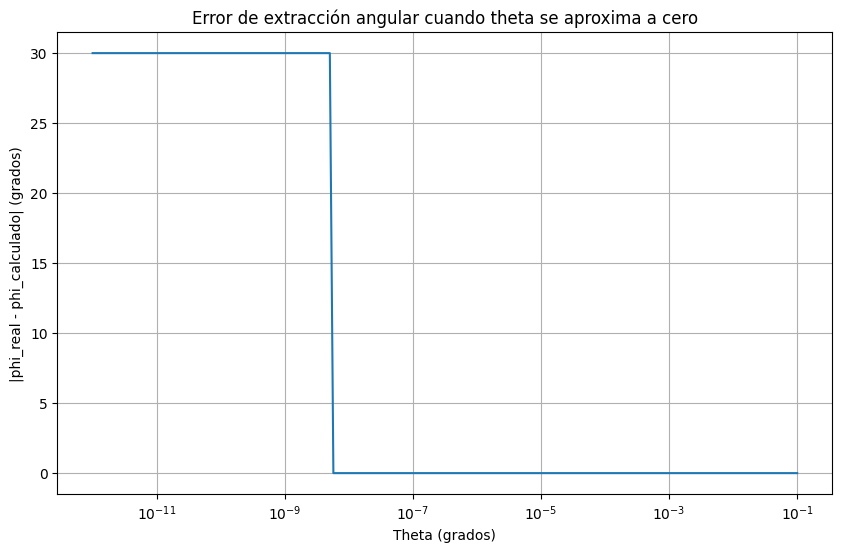

In [11]:
theta_values_deg = np.logspace(-12, -1, 200)

errores_phi = []

for theta_deg in theta_values_deg:

    theta_num = np.deg2rad(theta_deg)

    R_num = matriz_ZYZ(
        phi_real,
        theta_num,
        psi_real
    )

    phi_num, theta_rec, psi_num, singular_num = extraer_ZYZ(R_num)

    phi_num_deg = np.rad2deg(phi_num)

    # Error angular absoluto
    error_phi = abs(phi_real_deg - phi_num_deg)

    errores_phi.append(error_phi)

plt.figure(figsize=(10, 6))

plt.semilogx(theta_values_deg, errores_phi)

plt.xlabel("Theta (grados)")
plt.ylabel("|phi_real - phi_calculado| (grados)")
plt.title("Error de extracción angular cuando theta se aproxima a cero")
plt.grid(True)

plt.show()

## Análisis de resultados

La simulación muestra dos comportamientos importantes:

1. **Lejos de la singularidad**, la matriz de rotación contiene suficiente información para recuperar \(\phi\), \(\theta\) y \(\psi\).

2. **Cuando \(\theta\rightarrow0\)**, las componentes asociadas a la separación entre \(\phi\) y \(\psi\) se vuelven extremadamente pequeñas. En el límite \(\theta=0\), solamente permanece observable la combinación \(\phi+\psi\).

Por esta razón, pequeñas perturbaciones numéricas o decisiones de umbral pueden generar cambios grandes en los ángulos individuales recuperados, aunque la orientación física representada por la matriz siga siendo prácticamente la misma.
